## Experiment 5: Comparative Analysis of VGG, ResNet, and GoogLeNet on Image Classification


Training VGG...
VGG: Train Accuracy = 8.89%, Validation Accuracy = 26.67%

Training RESNET...
RESNET: Train Accuracy = 15.56%, Validation Accuracy = 6.67%

Training GOOGLENET...
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 155MB/s]


GOOGLENET: Train Accuracy = 8.89%, Validation Accuracy = 26.67%


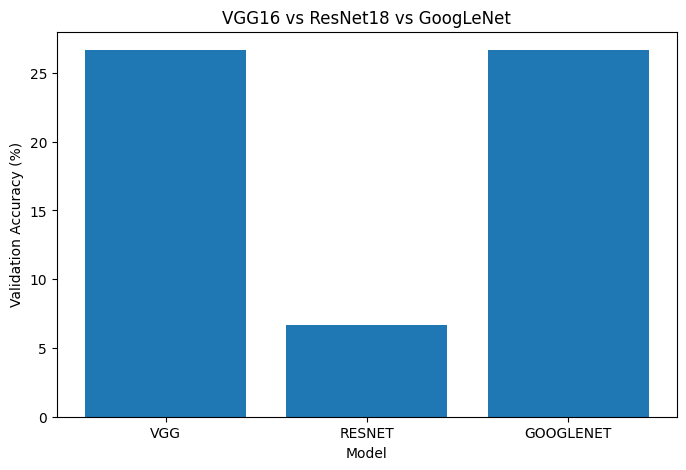

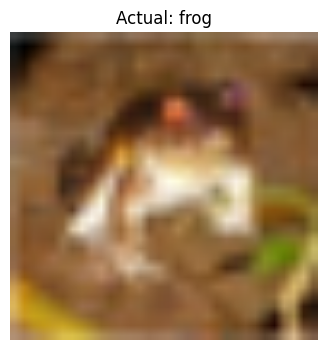


Prediction Results
VGG        => cat
RESNET     => truck
GOOGLENET  => truck


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataset = Subset(dataset, range(60))

train_dataset, val_dataset = random_split(
    dataset,
    [45,15],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset,batch_size=15,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=15,shuffle=False)

def get_model(name):
    if name == "vgg":
        model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        model.classifier[6] = nn.Linear(4096,10)
    elif name == "resnet":
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        model.fc = nn.Linear(model.fc.in_features,10)
    else:
        # Load with aux_logits=True since the weights dictionary expects it
        model = models.googlenet(weights=models.GoogLeNet_Weights.DEFAULT)
        for p in model.parameters():
            p.requires_grad = False
        # Redefine both fc and the auxiliary classifiers to output 10 classes
        model.fc = nn.Linear(model.fc.in_features, 10)
        if model.aux_logits:
            model.aux1.fc2 = nn.Linear(model.aux1.fc2.in_features, 10)
            model.aux2.fc2 = nn.Linear(model.aux2.fc2.in_features, 10)
    return model.to(device)

def train_model(model,name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p:p.requires_grad,model.parameters()),
        lr=0.001
    )
    model.train()
    correct = 0
    total = 0
    for images,labels in train_loader:
        images,labels = images.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)

        # GoogLeNet outputs GoogLeNetOutputs (named tuple with logits, aux_logits1, aux_logits2)
        # during training if aux_logits is True
        if isinstance(outputs, tuple) or (hasattr(outputs, 'logits') and name.lower() == 'googlenet'):
            main_outputs = outputs.logits
            loss = criterion(main_outputs, labels)
            if hasattr(outputs, 'aux_logits1'):
                loss += 0.3 * criterion(outputs.aux_logits1, labels)
            if hasattr(outputs, 'aux_logits2'):
                loss += 0.3 * criterion(outputs.aux_logits2, labels)
            outputs = main_outputs
        else:
            loss = criterion(outputs,labels)

        loss.backward()
        optimizer.step()
        _,predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    train_acc = 100*correct/total

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images,labels in val_loader:
            images,labels = images.to(device),labels.to(device)
            outputs = model(images)
            _,predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    val_acc = 100*correct/total
    print(f"{name}: Train Accuracy = {train_acc:.2f}%, Validation Accuracy = {val_acc:.2f}%")
    return model,val_acc

results = {}
trained_models = {}

for name in ["vgg","resnet","googlenet"]:
    print(f"\nTraining {name.upper()}...")
    try:
        model = get_model(name)
        trained_model,val_acc = train_model(model,name.upper())
        results[name] = val_acc
        trained_models[name] = trained_model
    except Exception as e:
        print(f"Failed to train {name.upper()}: {e}")

if results:
    plt.figure(figsize=(8,5))
    plt.bar(
        [x.upper() for x in results.keys()],
        results.values()
    )
    plt.xlabel("Model")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("VGG16 vs ResNet18 vs GoogLeNet")
    plt.show()

    image,label = dataset[0]
    plt.figure(figsize=(4,4))
    display_image = image.permute(1,2,0)
    display_image = display_image * 0.5 + 0.5
    plt.imshow(display_image)
    plt.title(f"Actual: {classes[label]}")
    plt.axis("off")
    plt.show()

    image = image.unsqueeze(0).to(device)
    print("\nPrediction Results")
    for name,model in trained_models.items():
        model.eval()
        with torch.no_grad():
            output = model(image)
            prediction = torch.argmax(output,dim=1).item()
        print(f"{name.upper():<10} => {classes[prediction]}")
else:
    print("No models were successfully trained.")